# Order Book Signals on Bond & Equity Calendar Spreads

## Setup

In [9]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
from plotnine import *
from plotnine.themes import theme_bw
import pandas as pd

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


polars.config.Config

In [4]:
from src.pipeline import build_datasets, generate_signals, TRAIN_YEARS, VAL_YEARS, TEST_YEARS, YEAR_LABEL

df_cs, df_combined = build_datasets(env_path='../.env')   # or pass session=snowpark to reuse a connection
df_signals = generate_signals(df_cs)                       # replaces cells 10–11

Phys qcodes : ['IE', 'GX', 'IL', 'GM', 'GH', 'BF', 'TU', 'FV']
Cash qcodes : ['ES', 'PI', 'HN', 'DF', 'AZ', 'FX', 'SV', 'NN', 'OX', 'TT']
binned   : (13901208, 12)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)


c:\Users\junwu.wang\Downloads\ip1\notebooks\..\src\pipeline.py:222: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


df_cs       : (190196, 32)
df_fut      : (1016010, 29)
df_combined : (1206206, 32)


In [5]:
# Curve group is tick-constrained if it exhibit all four characteristics

tick_constrained_bbg =['OE', 'XP', 'DU', 'IK', 'RX', 'QZ', 'FV', 'TU', 'VG', 'UB', 'OAT']


df_signals_tu = df_signals.filter(~pl.col('bbg_code').is_in(tick_constrained_bbg))
df_signals_tc = df_signals.filter(pl.col('bbg_code').is_in(tick_constrained_bbg))

df_signals_tc.describe()

statistic,qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,high,low,bbg_code,yellow_key,…,date,days_until,is_roll_period,futures_price,mid_price,obi,delta_p,delta_lb,delta_la,delta_p_bp,ofi,stv,noi,days_before,_tick
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,…,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""105380""","""105380""","""105380""","""105380""",105380.0,105380.0,105380.0,105380.0,105380.0,105380.0,105373.0,105373.0,"""105380""","""105380""",…,"""105380""",105380.0,105380.0,105380.0,105380.0,105380.0,105380.0,105380.0,105380.0,105380.0,104394.0,104396.0,104396.0,105380.0,105380.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,"""0""","""0""",…,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,986.0,984.0,984.0,0.0,0.0
"""mean""",null,null,"""12:49:31.500284""","""2023-07-06 07:04:15.942304""",201975.187151,214610.263114,1.103883,1.176301,3720.237417,25.268372,1.179014,1.101975,null,null,…,"""2023-07-06 07:04:15.942304""",3.253568,1.0,810.614925,1.140092,-0.016186,0.006719,-712.777984,2884.887673,0.003846,0.005373,0.001932,0.003624,3.253568,0.036118
"""std""",null,null,null,null,834548.538216,858838.530611,14.84845,14.886758,14725.98892,10774.440352,14.890162,14.847199,null,null,…,null,1.444381,null,1780.19208,14.867321,0.463784,0.986886,197001.96447,185755.567295,0.476145,0.973407,1.010914,0.981647,1.444381,0.093299
"""min""","""BF""","""DU2021H/2021M Comdty""","""07:05:00""","""2021-01-25""",1.0,1.0,-57.0,-56.0,0.0,-730759.0,-56.0,-57.0,"""DU""","""Comdty""",…,"""2021-01-25""",1.0,1.0,101.166653,-56.5,-0.999972,-40.0,-7.166885e6,-5.647385e6,-22.240716,-7.579892,-7.592764,-6.473674,1.0,0.001953
"""25%""",null,null,"""10:35:00""","""2022-03-15""",3983.0,3919.0,-0.429688,-0.42,173.0,-254.0,-0.417969,-0.429688,null,null,…,"""2022-03-15""",2.0,null,115.609876,-0.425,-0.293453,0.0,-540.0,-582.0,0.0,-0.293381,-0.549103,-0.654581,2.0,0.005
"""50%""",null,null,"""12:50:00""","""2023-06-06""",15704.0,17282.0,0.27,0.3,702.0,6.0,0.295,0.27,null,null,…,"""2023-06-06""",3.0,null,134.002773,0.275,-0.017627,0.0,-24.0,-35.0,0.0,0.004925,0.010105,0.008336,3.0,0.005
"""75%""",null,null,"""15:00:00""","""2024-09-18""",55780.0,58868.0,0.94,0.95,2663.0,331.0,0.96,0.94,null,null,…,"""2024-09-18""",4.0,null,298.52732,0.945,0.254925,0.0,615.0,614.0,0.0,0.301484,0.549754,0.660817,4.0,0.025
"""max""","""TU""","""XP2025Z/2026H Index""","""18:00:00""","""2025-12-29""",8.302973e6,9.625817e6,111.0,113.0,1.170799e6,449539.0,113.0,111.0,"""XP""","""Index""",…,"""2025-12-29""",10.0,1.0,8869.071429,112.0,0.999938,86.0,6.225243e6,5.853123e6,51.871226,7.587787,7.386721,6.079157,10.0,0.5


# Tick-constrained curve groups

Tick-constrained groups trade on a near-discrete price grid, so $\Delta P_t$ is cleaned to the
ordered set $\{-2, 0, +2\}$ (neighbour-context rules applied within each `[security, date]`
session over the full 2021-2025 sample) and modelled with a **class-weighted ordered logit**.

**Out-of-sample protocol.** Both the contemporaneous and the 1-step-ahead models are
- **trained** on 2021-2023 only, weighting the $\pm2$ minority tails by their train inverse-frequency;
- **tuned** on validation (2024) — the tail-vs-majority decision threshold is chosen to maximise
  the macro-F1 rather than using naive arg-max-probability assignment;
- **evaluated** on the held-out test set (2025) with the validation-selected threshold.

In [6]:
# --- Clean delta_p for tick-constrained securities ----------------------------
# Applied across the FULL 2021-2025 sample, within each [security, date] session.
# Rules applied simultaneously to original values:
#  1. 0, ±2: keep as-is.
#  2. ±1:
#     a. prev was ±1 (original) → 0  (this row is the "consumed" second of a prior pair)
#     b. next is ±1 same sign    → ±2 (upgrade: full-tick move)
#     c. next is ±1 opp. sign    → 0  (noise / immediate reversal)
#     d. isolated ±1             → promote to ±2
#  3. |delta_p| > 2 → clip to sign * 2.
#  4. Keep only {-2, 0, 2}.

df_signals_tc_clean = (
    df_signals_tc
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p=pl.col('delta_p').cast(pl.Int32))
    .with_columns(
        _prev_dp=pl.col('delta_p').shift(1).over(['security', 'date']),
        _next_dp=pl.col('delta_p').shift(-1).over(['security', 'date']),
    )
    .with_columns(
        delta_p=(
            pl.when(pl.col('delta_p').abs() > 2)
            # Rule 3: clip to ±2
            .then(pl.col('delta_p').sign() * 2)
            .when(pl.col('delta_p').abs() == 1)
            # Rule 2: handle ±1 based on neighbour context
            .then(
                pl.when(pl.col('_prev_dp').abs() == 1)
                # 2a: consumed by prior pair → zero
                .then(pl.lit(0))
                .when(pl.col('_next_dp').abs() == 1)
                .then(
                    pl.when(
                        ((pl.col('_next_dp') > 0) & (pl.col('delta_p') > 0)) |
                        ((pl.col('_next_dp') < 0) & (pl.col('delta_p') < 0))
                    )
                    # 2b: same sign → upgrade to ±2
                    .then(pl.col('delta_p').sign() * 2)
                    # 2c: opposite sign → zero
                    .otherwise(pl.lit(0))
                )
                # 2d: isolated → promote to ±2
                .otherwise(pl.col('delta_p') * 2)
            )
            # Rule 1: 0, ±2 unchanged
            .otherwise(pl.col('delta_p'))
        )
    )
    .drop(['_prev_dp', '_next_dp'])
    # Within-session 1-step-ahead target + chronological split key, built BEFORE the split so
    # the shift never crosses a session/year boundary (last bin of each session -> null target).
    .with_columns(
        delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date']),
        year=pl.col('date').dt.year(),
    )
)

counts = df_signals_tc_clean['delta_p'].value_counts(sort=True)
print(counts)

shape: (3, 2)
┌─────────┬───────┐
│ delta_p ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 93165 │
│ 2       ┆ 6169  │
│ -2      ┆ 6046  │
└─────────┴───────┘


## OOS Setup & Helpers (Tick-Constrained)

`WeightedOrderedModel`, the train-derived class weight, and the shared helpers used by both
ordered-logit models below:
- `fit_weighted_olr` — fit on **train (2021-2023)** with **cluster-robust SE** (clustered on the
  `[security, date]` session, so the stacked panel does not induce spurious dependence at
  security boundaries), then predict class probabilities for train / val / test;
- `tune_threshold` — pick the macro-F1-optimal tail-vs-majority decision boundary on
  **validation (2024)**;
- `pr_threshold_df` / `confusion_tile` — plotnine precision-recall and confusion-matrix plots;
- `report_all_splits` — classification reports (precision / recall / F1 / support) per split.

In [7]:
# === OOS setup for the tick-constrained ordered-logit models ===
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, f1_score,
)

CATS        = [-2, 0, 2]            # ordered target categories
TC_FEATURES = ['obi', 'noi', 'stv']

# Class weight on the ±2 minority tails = inverse frequency relative to the 0 class, computed
# on the TRAIN slice ONLY (deriving it from full-sample counts would leak val/test class balance
# into a training hyperparameter).
_tr_counts = (
    df_signals_tc_clean.filter(pl.col('year').is_in(TRAIN_YEARS))['delta_p'].value_counts()
)
CLASS_WEIGHT_MINOR = (
    _tr_counts.filter(pl.col('delta_p') == 0)['count'].item()
    / _tr_counts.filter(pl.col('delta_p') == 2)['count'].item()
)
print(f'Train class weight on +/-2 tails (count[0] / count[+2]) = {CLASS_WEIGHT_MINOR:.1f}x')


class WeightedOrderedModel(OrderedModel):
    """OrderedModel with per-observation class weights. Overriding loglikeobs propagates the
    weights into both the optimisation objective and the score_obs used by the robust sandwich."""

    def __init__(self, endog, exog, obs_weights=None, **kwargs):
        super().__init__(endog, exog, **kwargs)
        n = len(np.asarray(endog))
        self._obs_weights = (
            np.ones(n) if obs_weights is None else np.asarray(obs_weights, dtype=float)
        )

    def loglikeobs(self, params):
        return super().loglikeobs(params) * self._obs_weights


def _tc_frame(target_col, feature_cols, years):
    """Materialise a chronological slice of the cleaned tick-constrained data to pandas ONCE,
    carrying the target, the features, and a `cluster` key = security|date (the intraday
    session). Row order [security, date, bin_start_time] is preserved."""
    pdf = (
        df_signals_tc_clean
        .filter(pl.col('year').is_in(years))
        .select([target_col, *feature_cols, 'security', 'date'])
        .drop_nulls()
        .to_pandas()
    )
    pdf['cluster'] = pdf['security'].astype(str) + '|' + pdf['date'].astype(str)
    return pdf


def fit_weighted_olr(target_col, feature_cols, label):
    """Fit the class-weighted ordered logit on TRAIN (2021-2023) with CLUSTER-ROBUST SE
    (clustered on the [security, date] session — see note: a linear HAC across the stacked panel
    would fabricate dependence at security boundaries), then return (result, {split: (y_int,
    probs)}) with predicted class probabilities for each split."""
    tr     = _tc_frame(target_col, feature_cols, TRAIN_YEARS)
    y_tr   = tr[target_col].astype(int).values
    endog  = pd.Categorical(y_tr, categories=CATS, ordered=True)
    weights = np.where(y_tr == 0, 1.0, CLASS_WEIGHT_MINOR)

    res = WeightedOrderedModel(endog, tr[feature_cols], obs_weights=weights, distr='logit').fit(
        method='bfgs', cov_type='cluster', cov_kwds={'groups': tr['cluster'].values}, disp=False,
    )
    print(f'=== {label}:  {target_col} ~ {" + ".join(feature_cols)}  '
          f'(train 2021-2023, n={len(tr):,}, clusters={tr["cluster"].nunique():,}) ===')
    print('train class counts:', dict(pd.Series(y_tr).value_counts().reindex(CATS).items()))
    print(res.summary())

    out = {}
    for name, years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
        fr = _tc_frame(target_col, feature_cols, years)
        out[name] = (fr[target_col].astype(int).values, np.asarray(res.predict(exog=fr[feature_cols])))
    return res, out


def assign_classes(probs, thr):
    """Tail-vs-majority decision rule: +2 if P(+2) >= thr, else -2 if P(-2) >= thr, else 0.
    `probs` columns are ordered as CATS = [-2, 0, +2]."""
    return np.where(probs[:, 2] >= thr, 2, np.where(probs[:, 0] >= thr, -2, 0))


def tune_threshold(y_val, probs_val, grid=None):
    """Choose the single decision threshold maximising macro-F1 over {-2, 0, +2} on the
    VALIDATION set. Returns (best_thr, best_macro_f1, sweep_dataframe)."""
    if grid is None:
        grid = np.round(np.linspace(0.10, 0.95, 171), 4)
    rows = [(thr, f1_score(y_val, assign_classes(probs_val, thr),
                           labels=CATS, average='macro', zero_division=0)) for thr in grid]
    sweep = pd.DataFrame(rows, columns=['Threshold', 'MacroF1'])
    best  = sweep.loc[sweep['MacroF1'].idxmax()]
    return float(best['Threshold']), float(best['MacroF1']), sweep


def pr_threshold_df(y_val, probs_val):
    """Tidy precision/recall-vs-threshold for the two tail classes (validation data)."""
    frames = []
    for cls, col in ((-2, 0), (2, 2)):
        prec, rec, thr = precision_recall_curve((y_val == cls).astype(int), probs_val[:, col])
        frames.append(pd.DataFrame({
            'Threshold': thr, 'Precision': prec[:-1], 'Recall': rec[:-1], 'Class': f'Class {cls:+d}',
        }))
    return pd.concat(frames, ignore_index=True).melt(
        id_vars=['Threshold', 'Class'], value_vars=['Precision', 'Recall'],
        var_name='Metric', value_name='Value',
    )


def report_all_splits(data, thr, label):
    """Print classification reports (precision / recall / F1 / support) at `thr` for every split."""
    for name in ('train', 'val', 'test'):
        y, probs = data[name]
        pred = assign_classes(probs, thr)
        print(f'\n--- {label} | {name} ({YEAR_LABEL[name]}) | thr={thr:.3f} | '
              f'accuracy={(pred == y).mean():.4f} | n={len(y):,} ---')
        print(classification_report(y, pred, labels=CATS,
                                    target_names=['-2', '0', '+2'], zero_division=0))


def confusion_tile(y_true, y_pred, title):
    """plotnine confusion-matrix heatmap with raw counts and row percentages."""
    cm = confusion_matrix(y_true, y_pred, labels=CATS)
    cm_long = (
        pd.DataFrame(cm, index=CATS, columns=CATS)
        .rename_axis('Actual').reset_index()
        .melt(id_vars='Actual', var_name='Predicted', value_name='n')
        .assign(
            row_pct=lambda d: 100 * d['n'] / d.groupby('Actual')['n'].transform('sum'),
            label=lambda d: d.apply(lambda r: f"{int(r['n'])}\n({r['row_pct']:.1f}%)", axis=1),
        )
    )
    for col, order in [('Predicted', ['-2', '0', '2']), ('Actual', ['2', '0', '-2'])]:
        cm_long[col] = pd.Categorical(cm_long[col].astype(str), categories=order)
    return (
        ggplot(cm_long, aes(x='Predicted', y='Actual', fill='row_pct'))
        + geom_tile(color='white', size=0.5)
        + geom_text(aes(label='label'), size=9)
        + scale_fill_gradient(low='#f0f4ff', high='#2166ac', name='Row %')
        + labs(title=title, x='Predicted ΔP', y='Actual ΔP')
        + theme_bw(base_size=11) + theme(figure_size=(5, 4))
    )

Train class weight on +/-2 tails (count[0] / count[+2]) = 11.8x


## Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Class-weighted ordered logit with **cluster-robust** standard errors (clustered on the
`[security, date]` session, not a linear HAC across the stacked panel), **fit on train (2021-2023)**:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables $\mathbf{x}_t = [OBI_t,\ NOI_t,\ STV_t]$; target $\Delta P_t \in \{-2, 0, 2\}$.
The tail-vs-majority decision threshold is tuned on validation (2024) and applied to test (2025).

In [ ]:
# --- Contemporary baseline: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Features OBI, NOI, STV (no constant — ordered logit estimates the cut-points instead).
res_contemp, data_contemp = fit_weighted_olr('delta_p', TC_FEATURES, 'Contemporaneous (tick-constrained)')

In [ ]:
# --- Tune the decision threshold on VALIDATION (2024) -----------------------
# Sweep the tail-vs-majority boundary to maximise macro-F1; compare to naive arg-max-prob.
y_val_c, probs_val_c = data_contemp['val']

PROB_THRESH, best_f1_c, sweep_c = tune_threshold(y_val_c, probs_val_c)
argmax_f1_c = f1_score(y_val_c, np.array(CATS)[probs_val_c.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal PROB_THRESH = {PROB_THRESH:.3f}  '
      f'(val macro-F1 = {best_f1_c:.4f}  vs  arg-max-prob = {argmax_f1_c:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_c = pr_threshold_df(y_val_c, probs_val_c)
(
    ggplot(pr_long_c, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=PROB_THRESH, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Contemporaneous (PROB_THRESH = {PROB_THRESH:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)

In [ ]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
# Train / val / test classification reports at the SAME validation-selected PROB_THRESH,
# then the held-out 2025 confusion matrix (raw counts + row %).
report_all_splits(data_contemp, PROB_THRESH, 'Contemporaneous')

y_test_c, probs_test_c = data_contemp['test']
confusion_tile(
    y_test_c, assign_classes(probs_test_c, PROB_THRESH),
    title=f'Test (2025) Confusion — Ordered Logit Contemporaneous  (thr = {PROB_THRESH:.3f})',
)

## Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical class-weighted ordered logit, but the target is $\Delta P_{t+1}$ — the next bin's
**cleaned** price change, shifted into the current row with `.shift(-1).over(['security', 'date'])`
in the cleaning step (before the split), so there is no look-ahead leakage across sessions or
years. Trained on 2021-2023, threshold tuned on validation (2024), evaluated on test (2025).

In [10]:
# --- Predictive 1-step-ahead: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Target delta_p_fwd = next bin's cleaned delta_p, built within each [security, date] session
# in the cleaning cell (before the split) — no look-ahead across sessions or year boundaries.
res_fwd, data_fwd = fit_weighted_olr('delta_p_fwd', TC_FEATURES, 'Predictive 1-step (tick-constrained)')

=== Predictive 1-step (tick-constrained):  delta_p_fwd ~ obi + noi + stv  (train 2021-2023, n=63,609, clusters=602) ===
train class counts: {-2: 4490, 0: 54509, 2: 4610}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.2973e+05
Model:             WeightedOrderedModel   AIC:                         2.595e+05
Method:              Maximum Likelihood   BIC:                         2.595e+05
Date:                  Mon, 15 Jun 2026                                         
Time:                          10:05:20                                         
No. Observations:                 63609                                         
Df Residuals:                     63604                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------

Validation-optimal THRESH_FWD = 0.745  (val macro-F1 = 0.6006  vs  arg-max-prob = 0.4019)


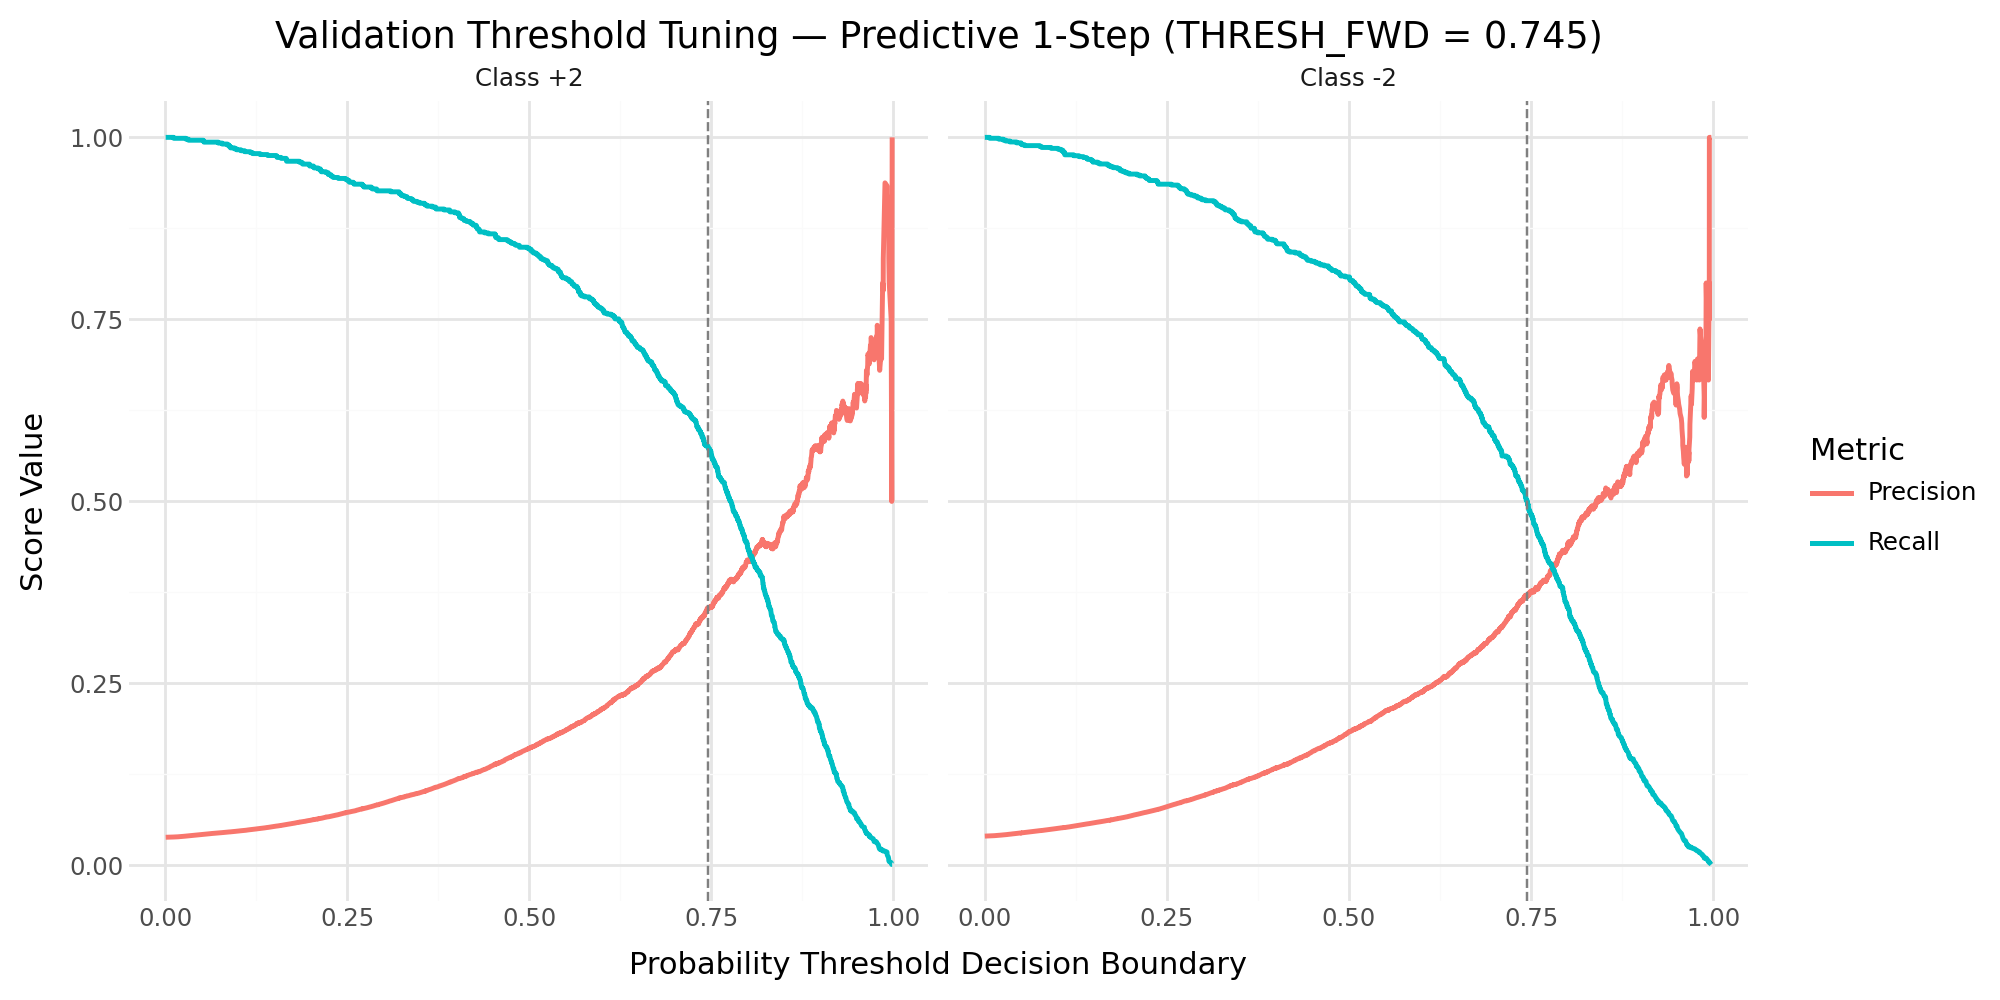

In [11]:
# --- Tune the predictive decision threshold on VALIDATION (2024) ------------
y_val_f, probs_val_f = data_fwd['val']

THRESH_FWD, best_f1_f, sweep_f = tune_threshold(y_val_f, probs_val_f)
argmax_f1_f = f1_score(y_val_f, np.array(CATS)[probs_val_f.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal THRESH_FWD = {THRESH_FWD:.3f}  '
      f'(val macro-F1 = {best_f1_f:.4f}  vs  arg-max-prob = {argmax_f1_f:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_f = pr_threshold_df(y_val_f, probs_val_f)
(
    ggplot(pr_long_f, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=THRESH_FWD, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step (THRESH_FWD = {THRESH_FWD:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step | train (2021-2023) | thr=0.745 | accuracy=0.8271 | n=63,609 ---
              precision    recall  f1-score   support

          -2       0.36      0.34      0.35      4490
           0       0.89      0.91      0.90     54509
          +2       0.39      0.35      0.37      4610

    accuracy                           0.83     63609
   macro avg       0.55      0.53      0.54     63609
weighted avg       0.82      0.83      0.82     63609


--- Predictive 1-step | val (2024) | thr=0.745 | accuracy=0.8888 | n=19,684 ---
              precision    recall  f1-score   support

          -2       0.37      0.50      0.42       793
           0       0.96      0.92      0.94     18129
          +2       0.35      0.58      0.44       762

    accuracy                           0.89     19684
   macro avg       0.56      0.66      0.60     19684
weighted avg       0.91      0.89      0.90     19684


--- Predictive 1-step | test (2025) | thr=0.745 | accuracy=0.8879 | 

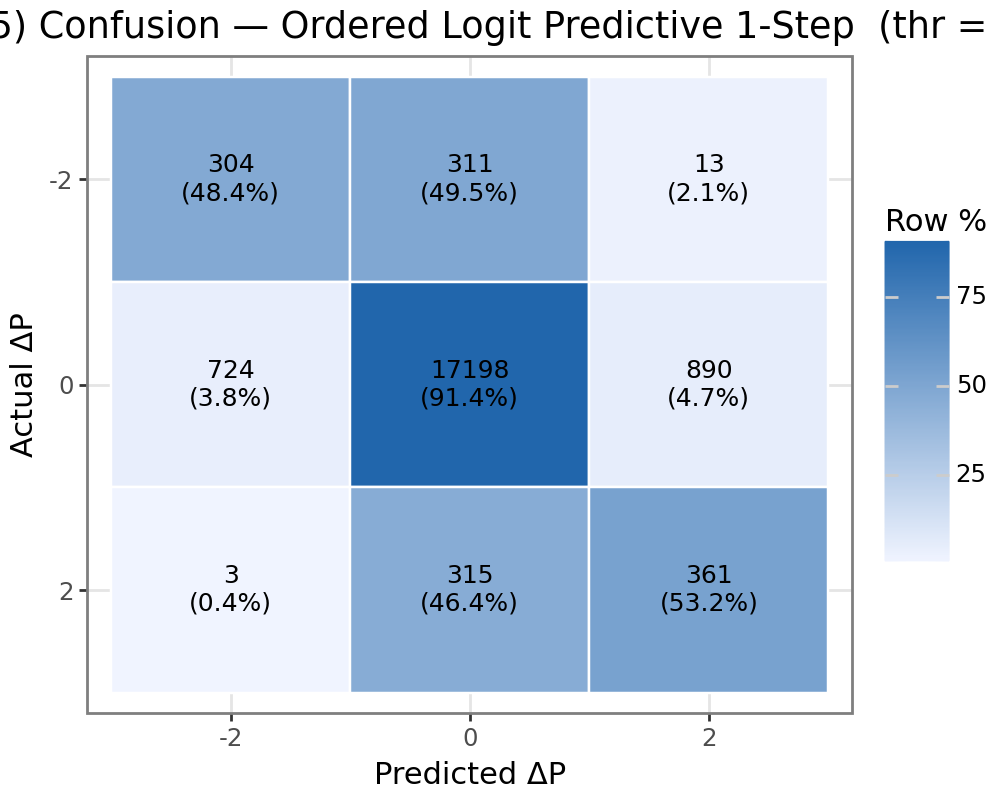

In [12]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
report_all_splits(data_fwd, THRESH_FWD, 'Predictive 1-step')

y_test_f, probs_test_f = data_fwd['test']
confusion_tile(
    y_test_f, assign_classes(probs_test_f, THRESH_FWD),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step  (thr = {THRESH_FWD:.3f})',
)

### Cross-`bbg_code` performance of the predictive model

The split-level reports above pool every tick-constrained curve group together. To check whether
the 1-step-ahead model is uniformly useful or only works on a subset, we break the **test (2025)**
tail performance out **by `bbg_code`**. The $+2$ and $-2$ classes are symmetric, so for each group
we report the **mean precision** and **mean recall** over the two tails (using the same fitted
model `res_fwd` and the same validation-tuned `THRESH_FWD`). Groups are ordered best → worst by
$\tfrac12(\text{precision} + \text{recall})$; `tail_support` is the count of actual $\pm2$ events,
so thin bars on tiny support should be read with caution.

bbg_code  Precision   Recall  tail_support    n   MeanPR
      RX   0.305648 0.885449            36 1972 0.595548
      DU   0.452143 0.704631           108 1624 0.578387
      IK   0.438742 0.618736           152 1534 0.528739
      OE   0.390750 0.614469            81 1740 0.502609
      QZ   0.325092 0.540230           206 4230 0.432661
      UB   0.292857 0.542157            64 1624 0.417507
      XP   0.302941 0.468750            24  592 0.385846
      TU   0.235177 0.481523           219 1615 0.358350
      FV   0.138767 0.548748            79 1710 0.343758
     OAT   0.286977 0.391281           136 1624 0.339129
      VG   0.306397 0.283688           202 1854 0.295043


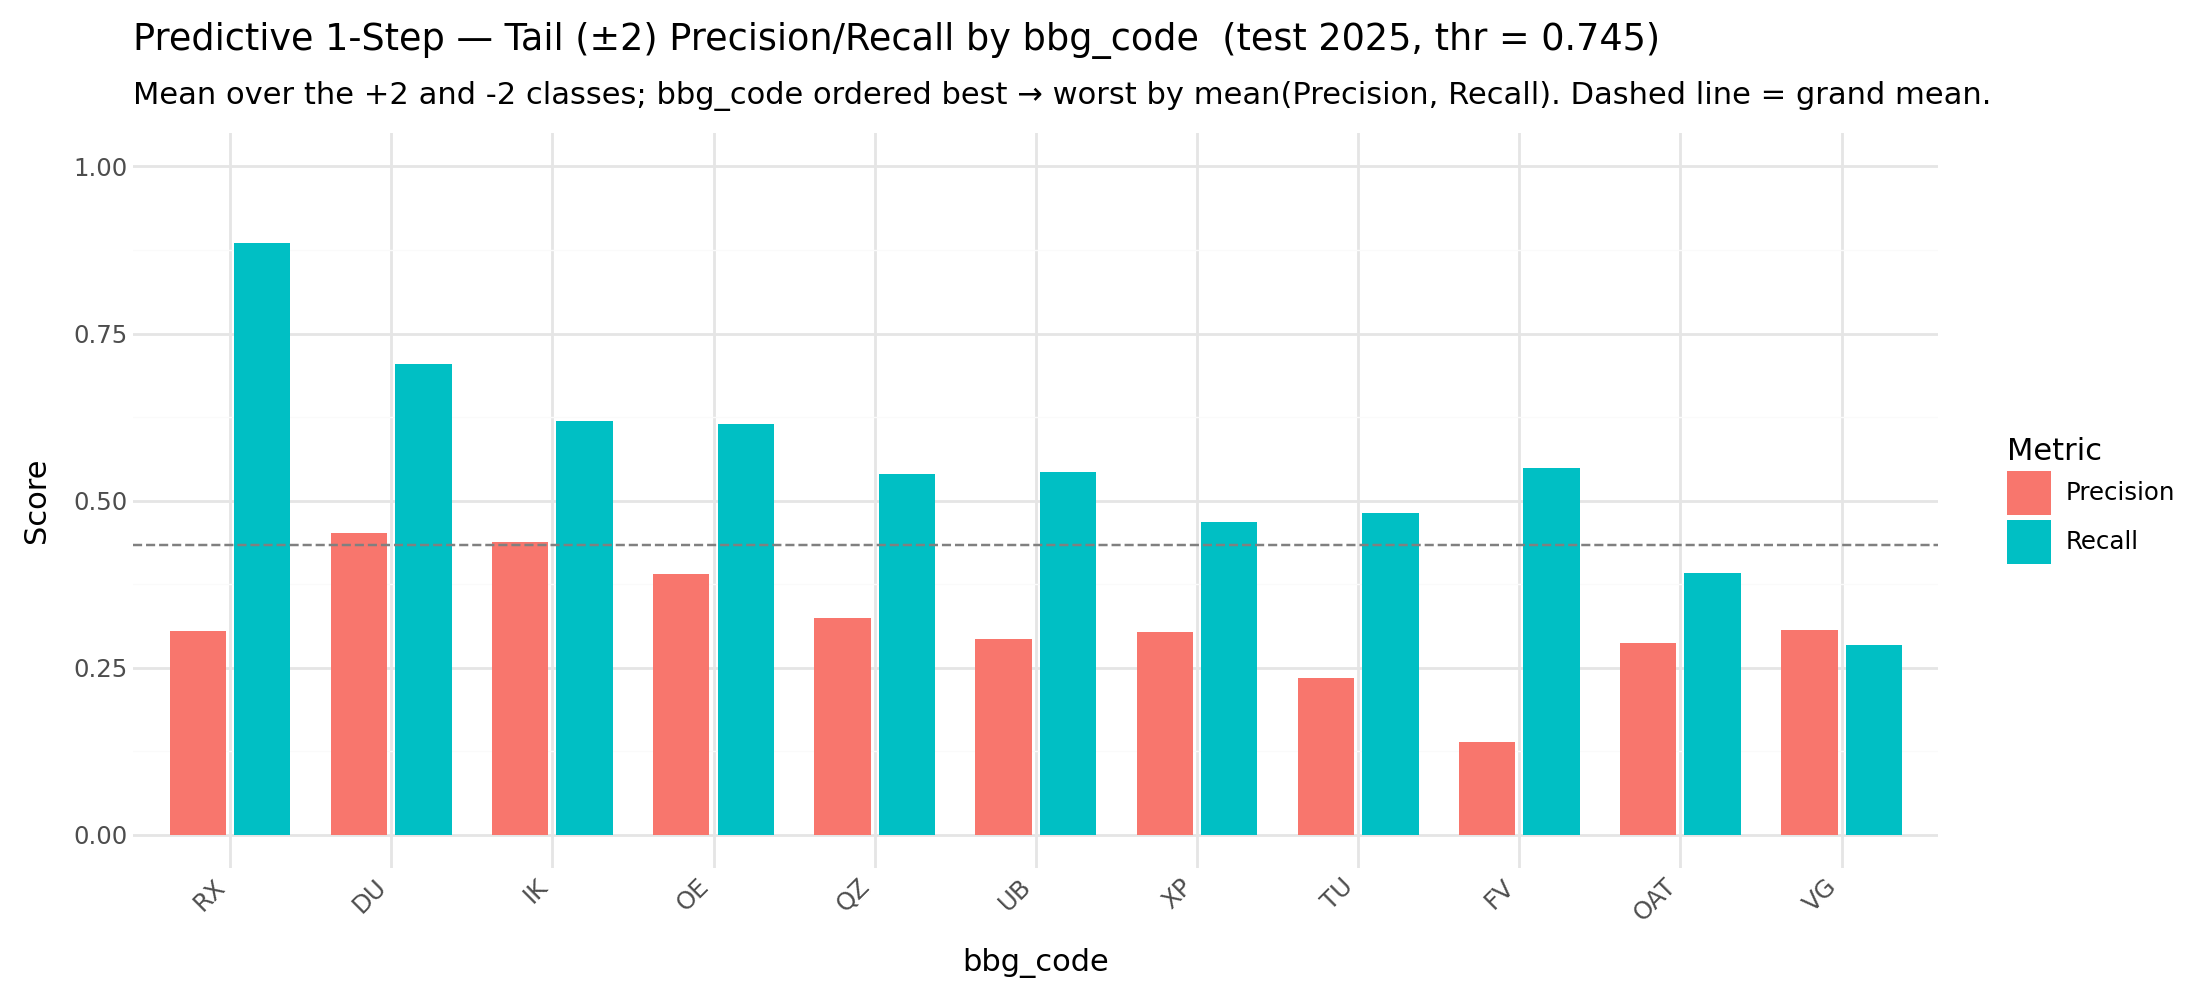

In [13]:
# --- Per-bbg_code evaluation of the predictive model on TEST (2025) ----------
# Tail (+/-2) precision & recall, averaged over the two tail classes (they are symmetric),
# computed SEPARATELY for each bbg_code so we can see where the 1-step-ahead model
# generalises and where it degrades. Uses the SAME fitted model (res_fwd) and the SAME
# validation-tuned THRESH_FWD; we just re-materialise the test slice carrying bbg_code so
# every row can be grouped.
from sklearn.metrics import precision_recall_fscore_support

_pdf_bbg = (
    df_signals_tc_clean
    .filter(pl.col('year').is_in(TEST_YEARS))
    .select(['delta_p_fwd', *TC_FEATURES, 'bbg_code'])
    .drop_nulls()
    .to_pandas()
)
_pdf_bbg['y']    = _pdf_bbg['delta_p_fwd'].astype(int)
_pdf_bbg['pred'] = assign_classes(
    np.asarray(res_fwd.predict(exog=_pdf_bbg[TC_FEATURES])), THRESH_FWD
)

rows = []
for code, g in _pdf_bbg.groupby('bbg_code'):
    prec, rec, _, sup = precision_recall_fscore_support(
        g['y'], g['pred'], labels=[-2, 2], zero_division=0,
    )
    rows.append({
        'bbg_code': code,
        'Precision': float(prec.mean()),   # mean over the +2 and -2 classes
        'Recall': float(rec.mean()),
        'tail_support': int(sup.sum()),    # # of actual +/-2 observations
        'n': int(len(g)),
    })

bbg_metrics = (
    pd.DataFrame(rows)
    .assign(MeanPR=lambda d: (d['Precision'] + d['Recall']) / 2)
    .sort_values('MeanPR', ascending=False)
    .reset_index(drop=True)
)
print(bbg_metrics.to_string(index=False))

# Dodged precision/recall bars, bbg_code ordered best -> worst by mean(Precision, Recall).
_order   = bbg_metrics['bbg_code'].tolist()
_grand   = bbg_metrics[['Precision', 'Recall']].to_numpy().mean()
bbg_long = bbg_metrics.melt(
    id_vars=['bbg_code'], value_vars=['Precision', 'Recall'],
    var_name='Metric', value_name='Value',
)
bbg_long['bbg_code'] = pd.Categorical(bbg_long['bbg_code'], categories=_order, ordered=True)
(
    ggplot(bbg_long, aes(x='bbg_code', y='Value', fill='Metric'))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + geom_hline(yintercept=_grand, linetype='dashed', color='grey')
    + scale_y_continuous(limits=[0, 1])
    + labs(
        title=f'Predictive 1-Step — Tail (±2) Precision/Recall by bbg_code  '
              f'(test 2025, thr = {THRESH_FWD:.3f})',
        subtitle='Mean over the +2 and -2 classes; bbg_code ordered best → worst by '
                 'mean(Precision, Recall). Dashed line = grand mean.',
        x='bbg_code', y='Score', fill='Metric',
    )
    + theme_minimal()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=45, hjust=1))
)